In [1]:
import numpy as np
import pandas as pd

In [2]:
from omnixai.data.tabular import Tabular
from omnixai.preprocessing.tabular import TabularTransform
from omnixai.explainers.tabular import MACEExplainer
from omnixai.explainers.tabular import TabularExplainer

print("All MACE components loaded successfully")

c:\Users\acbriza\anaconda3\envs\mace\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


All MACE components loaded successfully


In [3]:
import sys 
sys.path.append('..')  
import warnings
warnings.filterwarnings('ignore')

In [4]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
adult = fetch_ucirepo(id=2) 

In [5]:
from omnixai.data.tabular import Tabular
from pathlib import Path

this_dir = Path.cwd()
print(this_dir)
data_path = Path(this_dir.parent / 'dataset' / 'adult' / 'adult.data')

# Load the dataset
feature_names = [
   "Age", "Workclass", "fnlwgt", "Education",
   "Education-Num", "Marital Status", "Occupation",
   "Relationship", "Race", "Sex", "Capital Gain",
   "Capital Loss", "Hours per week", "Country", "label"
]
df = pd.DataFrame(
  np.genfromtxt(data_path, delimiter=', ', dtype=str),
  columns=feature_names
)
tabular_data = Tabular(
   df,
   categorical_columns=[feature_names[i] for i in [1, 3, 5, 6, 7, 8, 9, 13]],
   target_column='label'
)

c:\Users\acbriza\OneDrive - ASIAN INSTITUTE OF MANAGEMENT\0 DISS\code\dpn-tony\module


In [6]:
df

,Age,Workclass,fnlwgt,Education,Education-Num,Marital Status,Occupation,Relationship,Race,Sex,Capital Gain,Capital Loss,Hours per week,Country,label
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [ ]:
import xgboost
import sklearn
from omnixai.preprocessing.tabular import TabularTransform
# Data preprocessing
transformer = TabularTransform().fit(tabular_data)
class_names = transformer.class_names
x = transformer.transform(tabular_data)
# Split into training and test datasets
train, test, train_labels, test_labels = \
    sklearn.model_selection.train_test_split(x[:, :-1], x[:, -1], train_size=0.80)
# Train an XGBoost model (the last column of `x` is the label column after transformation)
model = xgboost.XGBClassifier(n_estimators=300, max_depth=5)
model.fit(train, train_labels)
# Convert the transformed data back to Tabular instances

train_data = transformer.invert(train)
test_data = transformer.invert(test)

In [8]:
from omnixai.explainers.tabular import TabularExplainer
# Initialize a TabularExplainer
explainer = TabularExplainer(
  explainers=["lime", "shap", "mace", "pdp", "ale"], # The explainers to apply
  mode="classification",                             # The task type
  data=train_data,                                   # The data for initializing the explainers
  model=model,                                       # The ML model to explain
  preprocess=lambda z: transformer.transform(z),     # Converts raw features into the model inputs
  params={
     "mace": {"ignored_features": ["Sex", "Race", "Relationship", "Capital Loss"]}
  }                                                  # Additional parameters
)

In [9]:
# Generate explanations
test_instances = test_data[:5]
local_explanations = explainer.explain(X=test_instances)
global_explanations = explainer.explain_global(
    params={"pdp": {"features": ["Age", "Education-Num", "Capital Gain",
                                 "Capital Loss", "Hours per week", "Education",
                                 "Marital Status", "Occupation"]}}
)

100%|██████████| 5/5 [00:07<00:00,  1.48s/it]


In [16]:
local_explanations.keys()

odict_keys(['predict', 'lime', 'shap', 'mace'])

[<Figure size 640x480 with 1 Axes>,
 <Figure size 640x480 with 1 Axes>,
 <Figure size 640x480 with 1 Axes>,
 <Figure size 640x480 with 1 Axes>,
 <Figure size 640x480 with 1 Axes>]

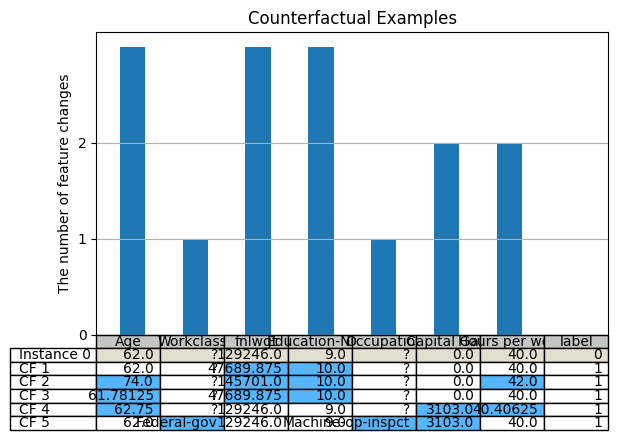

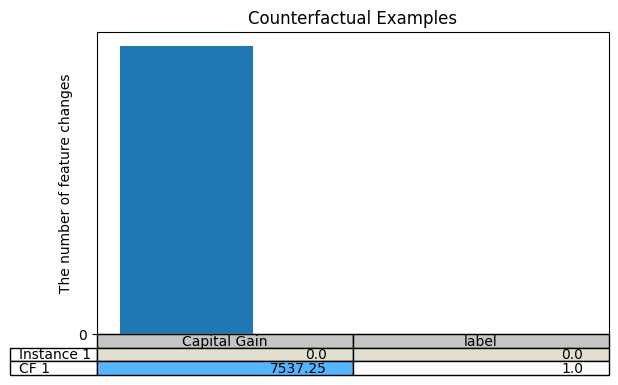

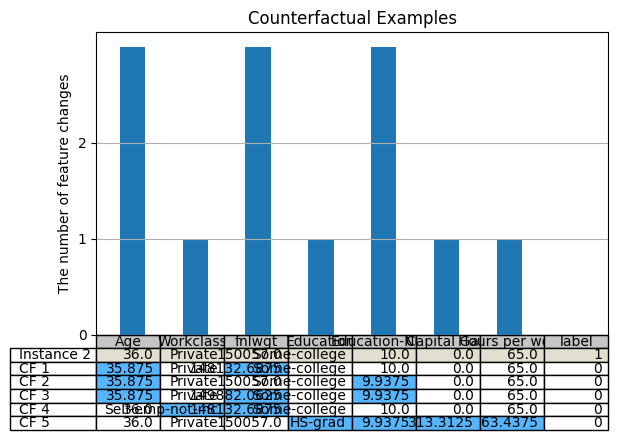

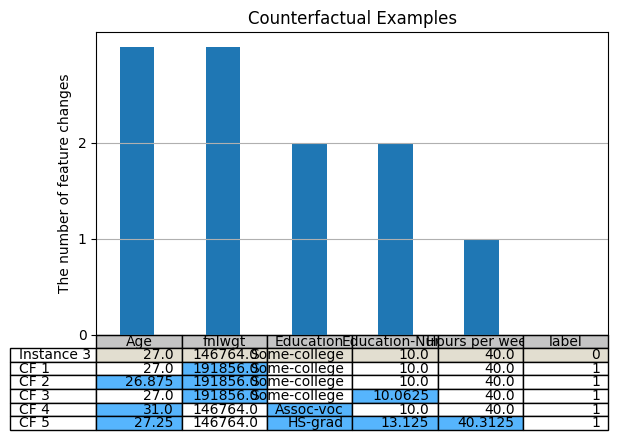

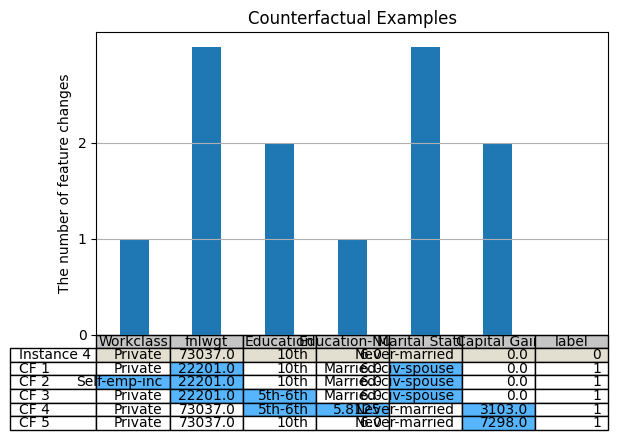

In [29]:
em=local_explanations['mace']
em.plot()

In [37]:
em.get_explanations()[0]['query']

,Age,Workclass,fnlwgt,Education,Education-Num,Marital Status,Occupation,Relationship,Race,Sex,Capital Gain,Capital Loss,Hours per week,Country,label
0,62.0,?,129246.0,HS-grad,9.0,Married-civ-spouse,?,Husband,White,Male,0.0,0.0,40.0,United-States,0


In [38]:
em.get_explanations()[0]['counterfactual']

,Age,Workclass,fnlwgt,Education,Education-Num,Marital Status,Occupation,Relationship,Race,Sex,Capital Gain,Capital Loss,Hours per week,Country,label
0,62.00000,?,47689.875,HS-grad,10.0,Married-civ-spouse,?,Husband,White,Male,0.0,0.0,40.00000,United-States,1
1,74.00000,?,145701.000,HS-grad,10.0,Married-civ-spouse,?,Husband,White,Male,0.0,0.0,42.00000,United-States,1
1,61.78125,?,47689.875,HS-grad,10.0,Married-civ-spouse,?,Husband,White,Male,0.0,0.0,40.00000,United-States,1
2,62.75000,?,129246.000,HS-grad,9.0,Married-civ-spouse,?,Husband,White,Male,3103.0,0.0,40.40625,United-States,1
6,62.00000,Federal-gov,129246.000,HS-grad,9.0,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,3103.0,0.0,40.00000,United-States,1


In [43]:
global_explanations.keys()

odict_keys(['pdp', 'ale'])

[<Figure size 640x480 with 1 Axes>,
 <Figure size 640x480 with 1 Axes>,
 <Figure size 640x480 with 1 Axes>,
 <Figure size 640x480 with 1 Axes>,
 <Figure size 640x480 with 1 Axes>,
 <Figure size 640x480 with 1 Axes>,
 <Figure size 640x480 with 1 Axes>,
 <Figure size 640x480 with 1 Axes>]

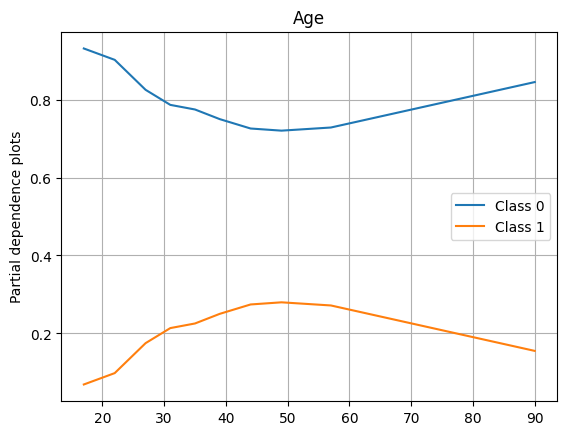

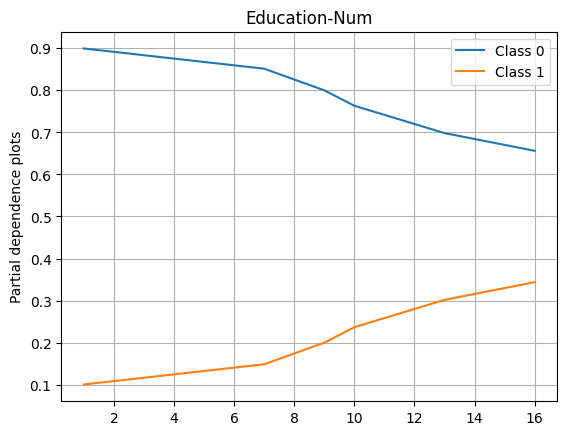

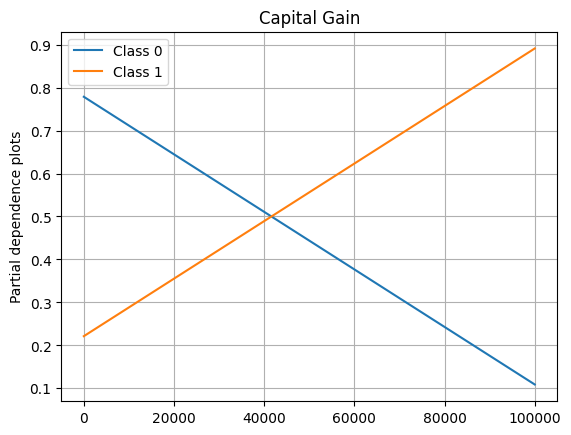

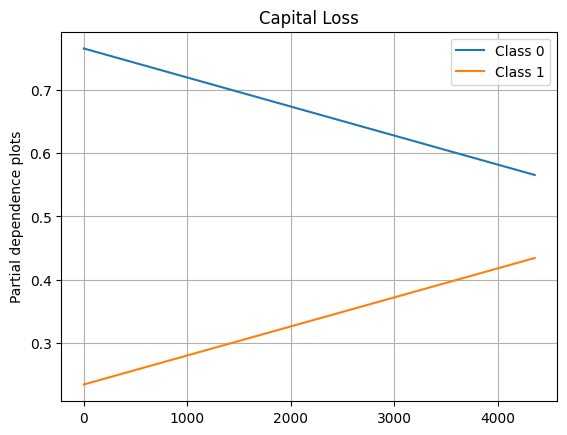

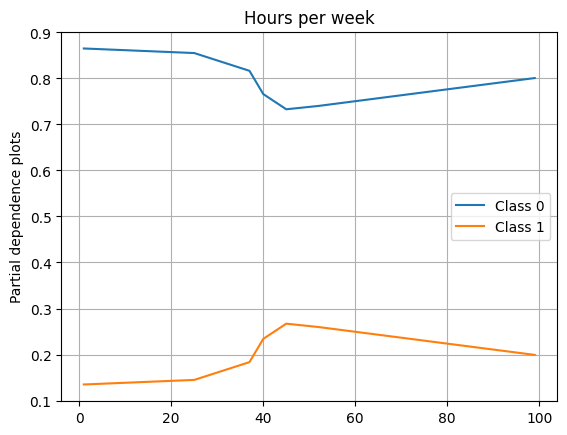

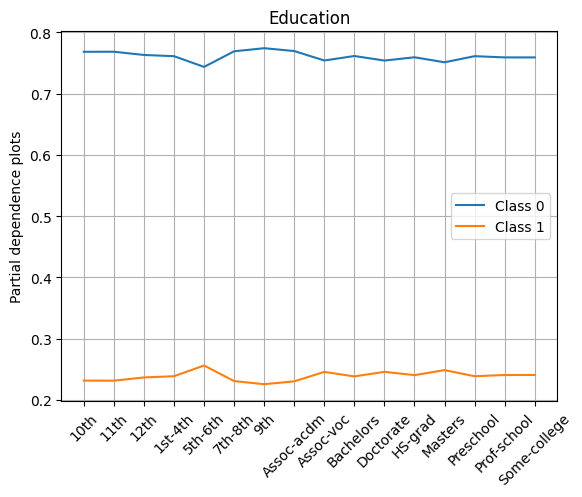

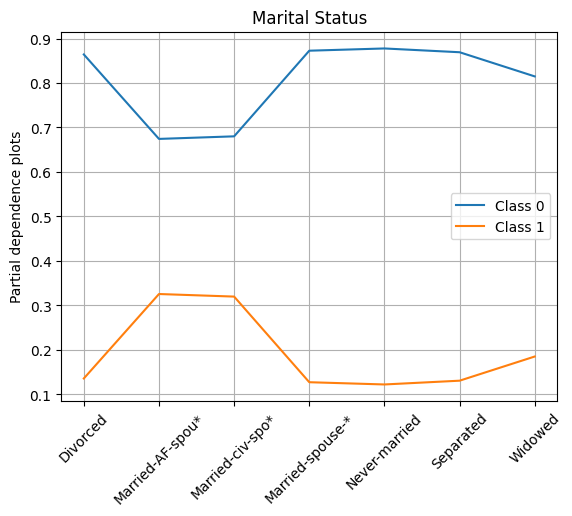

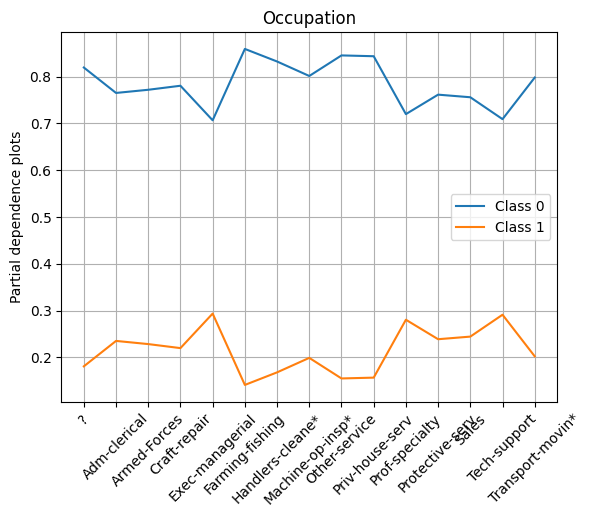

In [45]:
global_explanations['pdp'].plot()

In [10]:
from omnixai.explainers.prediction import PredictionAnalyzer

analyzer = PredictionAnalyzer(
    mode="classification",
    test_data=test_data,                           # The test dataset (a `Tabular` instance)
    test_targets=test_labels,                      # The test labels (a numpy array)
    model=model,                                   # The ML model
    preprocess=lambda z: transformer.transform(z)  # Converts raw features into the model inputs
)
prediction_explanations = analyzer.explain()

In [ ]:
from omnixai.visualization.dashboard import Dashboard
# Launch a dashboard for visualization
dashboard = Dashboard(
   instances=test_instances,                        # The instances to explain
   local_explanations=local_explanations,           # Set the local explanations
   global_explanations=global_explanations,         # Set the global explanations
   prediction_explanations=prediction_explanations, # Set the prediction metrics
   class_names=class_names,                         # Set class names
   explainer=explainer                              # The created TabularExplainer for what if analysis
)
dashboard.show()